In [3]:
import re
from collections import Counter
from pathlib import Path

import jieba
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset


class CBOWDataset(Dataset):

    def __init__(self, root, window_size=2, min_freq=2, max_vocab_size=50000):
        super().__init__()
        if window_size < 1:
            raise ValueError("window_size必须大于等于1")
        if min_freq < 1:
            raise ValueError("min_freq必须大于等于1")
        if max_vocab_size < 2:
            raise ValueError("max_vocab_size至少为2,需要容纳pad和unk")

        self.root = Path(root)
        self.window_size = window_size
        self.min_freq = min_freq
        self.max_vocab_size = max_vocab_size

        if not self.root.is_file():
            raise FileNotFoundError(f"找不到语料文件:{self.root}")

        self.create_vocab_index()
        self.create_context()

    @property
    def vocab_size(self) -> int:
        return len(self.vocab)

    def _load_text(self):
        with self.root.open("rt", encoding="utf-8") as file:
            for line in file:
                line = line.strip()
                if line:
                    yield line

    @staticmethod
    def _tokenize(line: str) -> list[str]:
        return [
            token
            for token in jieba.lcut(line)
            if re.search(r"\w", token)
        ]

    def create_vocab_index(self) -> None:
        counter = Counter()

        for line in self._load_text():
            counter.update(self._tokenize(line))

        special_tokens = ["<PAD>", "<UNK>"]
        available_size = self.max_vocab_size - len(special_tokens)

        valid_tokens = [
            token
            for token, count in counter.most_common()
            if count >= self.min_freq and token not in special_tokens
        ][:available_size]

        self.vocab = special_tokens + valid_tokens
        self.word2index = {
            word: index
            for index, word in enumerate(self.vocab)
        }
        self.index2word = {
            index: word
            for index, word in enumerate(self.vocab)
        }

    def create_context(self) -> None:
        self.contexts: list[list[int]] = []
        self.targets: list[int] = []

        pad_idx = self.word2index["<PAD>"]
        unk_idx = self.word2index["<UNK>"]
        window_size = self.window_size

        for line in self._load_text():
            sentence = self._tokenize(line)
            token_ids = [
                self.word2index.get(token, unk_idx)
                for token in sentence
            ]

            if not token_ids:
                continue

            padded_token_ids = (
                [pad_idx] * window_size
                + token_ids
                + [pad_idx] * window_size
            )

            for i, target in enumerate(token_ids):
                if target == unk_idx:
                    continue

                center_idx = i + window_size
                left_context = padded_token_ids[
                    center_idx - window_size:center_idx
                ]
                right_context = padded_token_ids[
                    center_idx + 1:center_idx + window_size + 1
                ]

                self.contexts.append(left_context + right_context)
                self.targets.append(target)

    def __len__(self) -> int:
        return len(self.targets)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        context_ids = torch.tensor(
            self.contexts[index],
            dtype=torch.long,
        )
        target = torch.tensor(
            self.targets[index],
            dtype=torch.long,
        )

        context_one_hot = F.one_hot(
            context_ids,
            num_classes=self.vocab_size,
        ).float()

        pad_idx = self.word2index["<PAD>"]
        pad_mask = (context_ids != pad_idx).unsqueeze(1)
        context_one_hot = context_one_hot * pad_mask

        return context_one_hot, target

In [4]:
import torch
import torch.nn as nn

class CBOWModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim = 32):
        super().__init__()
        self.embedding = nn.Linear(
            in_features=vocab_size,
            out_features=embedding_dim,
            bias=False
        )
        self.out = nn.Linear(
            in_features=embedding_dim,
            out_features=vocab_size,
        )
        
    def forward(self, context_one_hot: torch.Tensor) -> torch.Tensor:
        embedding = self.embedding(context_one_hot)
        valid_mask = (
            context_one_hot.sum(dim= -1, keepdim=True) > 0
        ).to(embedding.dtype)
        
        embedding_sum = (embedding * valid_mask).sum(dim = 1)
        no_pad_count = valid_mask.sum(dim=1).clamp(min=1)
        embedding_mean = embedding_sum / no_pad_count
        
        return self.out(embedding_mean)
    
    def get_token_embeddings(self) -> torch.Tensor:
        return self.embedding.weight.T

In [5]:
import copy
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader


BASE_DIR = Path.cwd()
DEFAULT_CORPUS = BASE_DIR / "sentence.txt"


def save_word_vectors(
    model: CBOWModel,
    dataset: CBOWDataset,
    file_path: str | Path,
) -> None:
    """把词向量保存成常见的 Word2Vec 文本格式。"""
    token_embeddings = (
        model.get_token_embeddings()
        .detach()
        .cpu()
        .numpy()
    )


    pad_idx = dataset.word2index["<PAD>"]
    valid_indices = [
        idx
        for idx in range(dataset.vocab_size)
        if idx != pad_idx
    ]
    embedding_dim = token_embeddings.shape[1]

    with Path(file_path).open("wt", encoding="utf-8") as file:

        file.write(f"{len(valid_indices)} {embedding_dim}\n")

        for idx in valid_indices:
            token = dataset.index2word[idx]
            vector_text = " ".join(
                f"{value:.6f}"
                for value in token_embeddings[idx]
            )
            file.write(f"{token} {vector_text}\n")


def train(
    corpus_path: str | Path = DEFAULT_CORPUS,
    window_size: int = 2,
    min_freq: int = 1,
    max_vocab_size: int = 50000,
    embedding_dim: int = 32,
    batch_size: int = 4,
    learning_rate: float = 0.01,
    epochs: int = 300,
) -> tuple[CBOWModel, CBOWDataset]:
    """完成数据加载、模型训练和最优参数保存。"""
    torch.manual_seed(42)

    dataset = CBOWDataset(
        root=corpus_path,
        window_size=window_size,
        min_freq=min_freq,
        max_vocab_size=max_vocab_size,
    )
    if len(dataset) == 0:
        raise ValueError(
            "没有生成训练样本，请检查语料，或适当降低 min_freq。"
        )

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
    )

    model = CBOWModel(
        vocab_size=dataset.vocab_size,
        embedding_dim=embedding_dim,
    )
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
    )

    best_loss = float("inf")
    best_state = None

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        total_samples = 0

        for context_one_hot, targets in dataloader:
            optimizer.zero_grad()

            logits = model(context_one_hot)
            loss = loss_fn(logits, targets)

            loss.backward()
            optimizer.step()

            current_batch_size = targets.size(0)
        
            total_loss += loss.item() * current_batch_size
            total_samples += current_batch_size

        avg_loss = total_loss / total_samples

        if avg_loss < best_loss:
            best_loss = avg_loss
            best_state = copy.deepcopy(model.state_dict())

        if epoch == 0 or (epoch + 1) % 20 == 0:
            print(
                f"Epoch [{epoch + 1:3d}/{epochs}], "
                f"Loss: {avg_loss:.6f}"
            )

    if best_state is None:
        raise RuntimeError("训练未产生有效的模型参数。")

    model.load_state_dict(best_state)

    checkpoint_path = BASE_DIR / "cbow_best.pt"
    vector_path = BASE_DIR / "word2vec.txt"

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "word2index": dataset.word2index,
            "index2word": dataset.index2word,
            "embedding_dim": embedding_dim,
            "window_size": window_size,
            "best_loss": best_loss,
        },
        checkpoint_path,
    )
    save_word_vectors(model, dataset, vector_path)

    print(f"训练完成，最优损失：{best_loss:.6f}")
    print(f"模型已保存到：{checkpoint_path}")
    print(f"词向量已保存到：{vector_path}")

    return model, dataset


if __name__ == "__main__":
    train()

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\13744\AppData\Local\Temp\jieba.cache
Loading model cost 0.620 seconds.
Prefix dict has been built successfully.


Epoch [  1/300], Loss: 4.789580
Epoch [ 20/300], Loss: 0.058342
Epoch [ 40/300], Loss: 0.020704
Epoch [ 60/300], Loss: 0.015194
Epoch [ 80/300], Loss: 0.013089
Epoch [100/300], Loss: 0.010739
Epoch [120/300], Loss: 0.011249
Epoch [140/300], Loss: 0.010738
Epoch [160/300], Loss: 0.010231
Epoch [180/300], Loss: 0.008697
Epoch [200/300], Loss: 0.010702
Epoch [220/300], Loss: 0.009058
Epoch [240/300], Loss: 0.009814
Epoch [260/300], Loss: 0.009669
Epoch [280/300], Loss: 0.008526
Epoch [300/300], Loss: 0.008303
训练完成，最优损失：0.008075
模型已保存到：d:\project\step3\week17\cbow_best.pt
词向量已保存到：d:\project\step3\week17\word2vec.txt


## 验证：词向量里到底学到了什么？

回到前面讨论的结论 —— CBOW 的"特征提取"本质是：**把 one-hot 正交基投影到一个低维稠密的语义子空间**。下面直接加载已训练好的 `cbow_best.pt`，做三件事来验证：

1. **查词**：用余弦相似度找某个词的"最近邻居"，看语义相近的词是否真的聚在一起；
2. **对比**：不同词的 One-Hot 余弦相似度恒为 0（两两正交）；训练后的稠密词向量相似度不再被固定为 0，根据向量方向**可能为正数，也可能为负数**（例如下面的"训练 / 预测"就是负的）；
3. **可视化**：把 32 维词向量用 PCA 压到 2 维，肉眼观察聚类结构。

In [6]:
import torch

# 直接使用本 notebook 第 2 个 cell 手写的 CBOWModel，不依赖 model.py
ckpt = torch.load("cbow_best.pt", map_location="cpu")

model = CBOWModel(
    vocab_size=len(ckpt["index2word"]),
    embedding_dim=ckpt["embedding_dim"],
)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

word2index = ckpt["word2index"]
index2word = {int(k): v for k, v in ckpt["index2word"].items()}

# [vocab_size, embedding_dim]：每一行就是一个词的稠密向量
embeddings = model.get_token_embeddings().detach()

print("词向量矩阵形状:", tuple(embeddings.shape))
print("词表大小:", len(index2word),
      "| 维度:", ckpt["embedding_dim"],
      "| 最优损失:", round(ckpt["best_loss"], 4))

词向量矩阵形状: (116, 32)
词表大小: 116 | 维度: 32 | 最优损失: 0.0081


In [7]:
import torch.nn.functional as F

# 归一化之后，向量点积 = 余弦相似度
norm_emb = F.normalize(embeddings, dim=1)


def nearest_neighbors(word: str, k: int = 6) -> None:
    """打印与 word 余弦相似度最高的 k 个词。"""
    idx = word2index.get(word)
    if idx is None:
        print(f"「{word}」不在词表中")
        return

    sims = (norm_emb @ norm_emb[idx]).clone()  # 与词表里所有词算余弦

    # 查询结果中不应出现自身、<PAD> 和 <UNK>。
    excluded_indices = {idx}
    for special_token in ("<PAD>", "<UNK>"):
        special_idx = word2index.get(special_token)
        if special_idx is not None:
            excluded_indices.add(special_idx)

    for excluded_idx in excluded_indices:
        sims[excluded_idx] = float("-inf")

    neighbor_count = min(k, len(word2index) - len(excluded_indices))
    if neighbor_count <= 0:
        print(f"「{word}」没有可比较的普通词")
        return
    top = torch.topk(sims, neighbor_count)

    print(f"\n「{word}」的最近邻居：")
    for i, s in zip(top.indices.tolist(), top.values.tolist()):
        print(f"    {index2word[i]:<6} {s:+.4f}")


for word in ["模型", "向量", "上下文", "训练", "损失", "预测", "语义"]:
    nearest_neighbors(word)


print("\n" + "=" * 44)
print("同一词对：one-hot 表示 vs 学到的稠密表示")
print("=" * 44)
print(f"{'词对':<14} {'one-hot 余弦':>12} {'稠密向量余弦':>12}")
pairs = [("模型", "训练"), ("上下文", "中心词"), ("训练", "预测"), ("模型", "词语")]
for w1, w2 in pairs:
    i1, i2 = word2index[w1], word2index[w2]
    one_hot_sim = 0.0                      # 不同 one-hot 两两正交
    dense_sim = float(norm_emb[i1] @ norm_emb[i2])
    print(f"{w1 + ' / ' + w2:<14} {one_hot_sim:>12.4f} {dense_sim:>12.4f}")


「模型」的最近邻居：
    开始     +0.5608
    层      +0.3653
    轮数     +0.3155
    效果     +0.2916
    我们     +0.2902
    保证     +0.2690

「向量」的最近邻居：
    未知     +0.5711
    多个     +0.5095
    为      +0.4699
    准确     +0.3799
    保证     +0.3791
    周围     +0.3769

「上下文」的最近邻居：
    符号     +0.3710
    提取     +0.3611
    衡量     +0.3531
    准确     +0.3368
    长度     +0.2840
    独热     +0.2503

「训练」的最近邻居：
    需要     +0.5811
    首先     +0.4872
    把      +0.4691
    衡量     +0.4451
    CBOW   +0.3963
    不断更新   +0.3611

「损失」的最近邻居：
    就      +0.4362
    熵      +0.3656
    反向     +0.3548
    逐渐     +0.3489
    以后     +0.3474
    求      +0.3397

「预测」的最近邻居：
    保证     +0.4053
    的      +0.3882
    多个     +0.3788
    表示     +0.3580
    我们     +0.3449
    用来     +0.3270

「语义」的最近邻居：
    映射     +0.6903
    参数     +0.5188
    高质量    +0.4806
    逐行     +0.4208
    中心词    +0.3805
    编号     +0.3740

同一词对：one-hot 表示 vs 学到的稠密表示
词对               one-hot 余弦       稠密向量余弦
模型 / 训练              0.0000       0.1545
上下文 / 中

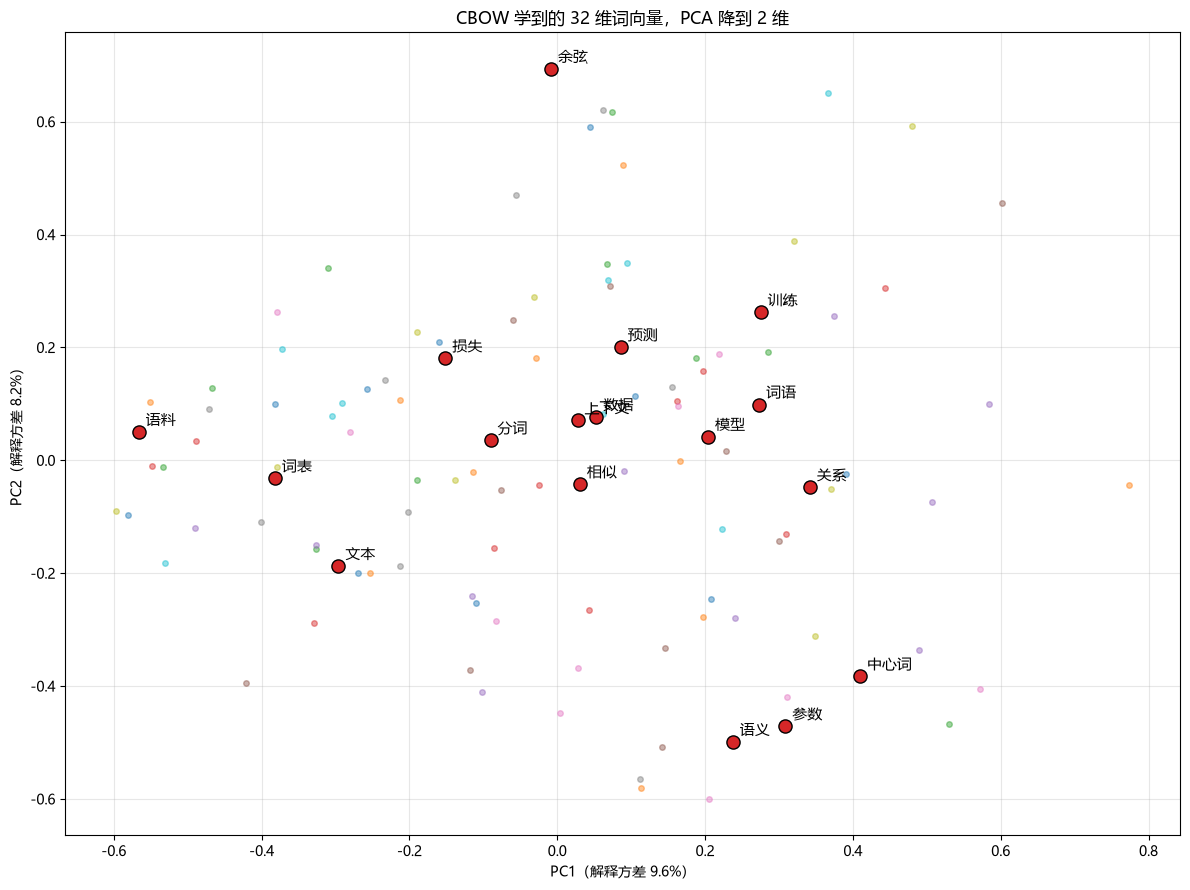

前两个主成分合计解释方差：17.8%


In [8]:
import matplotlib
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 让 matplotlib 正确显示中文
matplotlib.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
matplotlib.rcParams["axes.unicode_minus"] = False

# 只看真实词，丢弃 <PAD> / <UNK>
valid = [i for i in range(len(index2word)) if index2word[i] not in ("<PAD>", "<UNK>")]
words = [index2word[i] for i in valid]
vecs = norm_emb[valid].cpu().numpy()

# 32 维 -> 2 维
pca = PCA(n_components=2)
xy = pca.fit_transform(vecs)
coords = {w: xy[j] for j, w in enumerate(words)}

# 只给"语义重点词"标名字，其余画小点，避免图太挤
label_words = [
    "模型", "训练", "预测", "上下文", "中心词", "词向量", "词语",
    "词表", "语料", "分词", "文本", "数据", "损失", "相似",
    "余弦", "距离", "语义", "关系", "参数", "词频",
]
label_words = [w for w in label_words if w in coords]

fig, ax = plt.subplots(figsize=(12, 9))
for w, (x, y) in coords.items():
    if w in label_words:
        ax.scatter(x, y, s=90, c="tab:red", edgecolors="k", zorder=3)
    else:
        ax.scatter(x, y, s=16, alpha=0.45, zorder=2)

for w in label_words:
    x, y = coords[w]
    ax.annotate(w, (x, y), fontsize=11, xytext=(5, 5),
                textcoords="offset points")

ax.set_title("CBOW 学到的 32 维词向量，PCA 降到 2 维")
ax.set_xlabel(f"PC1（解释方差 {pca.explained_variance_ratio_[0]:.1%}）")
ax.set_ylabel(f"PC2（解释方差 {pca.explained_variance_ratio_[1]:.1%}）")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("前两个主成分合计解释方差："
      f"{pca.explained_variance_ratio_.sum():.1%}")

# CBOW 训练过程中的数学主线

> 这份 Notebook 表面上是在训练一个 CBOW 模型，实际上走完了一条完整的数学建模链路：**把离散符号变成向量，用概率定义预测目标，用优化算法学习参数，再用几何与统计方法检查结果。**

## 一、先看全流程

$$
\boxed{
\text{语料}
\rightarrow
\text{词表与编号}
\rightarrow
\text{上下文样本}
\rightarrow
\text{One-Hot}
\rightarrow
\text{词向量}
\rightarrow
\text{上下文均值}
\rightarrow
\text{中心词概率}
\rightarrow
\text{交叉熵}
\rightarrow
\text{反向传播}
}
$$

| Notebook 部分 | 数学对象 | 解决的问题 |
|---|---|---|
| Cell 1：Dataset | 频数、集合映射、局部窗口、掩码 | 如何把文本变成训练样本 |
| Cell 2：Model | 矩阵乘法、线性映射、向量平均 | 如何根据上下文计算预测 |
| Cell 3：Train | 条件概率、交叉熵、梯度、Adam | 如何让模型从数据中学习 |
| Cell 5～7：验证 | 内积、夹角、最近邻、PCA | 如何观察学到的词向量 |

## 二、Cell 1：从文本符号到数学对象

### 1. 词频统计：用样本频率估计词的出现概率

若整个语料一共有 $N$ 个 token，词 $w$ 出现了 $c(w)$ 次，那么它的经验概率为：

$$
\hat p(w)=\frac{c(w)}{N}
$$

`Counter` 得到的是 $c(w)$。`min_freq` 删除统计证据过少的词，`max_vocab_size` 保留最高频的一部分词，其余统一映射为 `<UNK>`。

这属于**词表截断与类别合并**：可以减少参数量和低频噪声，但不要把它严格等同于神经网络正则化。

### 2. 词表编号：建立有限集合之间的映射

`word2index` 建立：

$$
f:\text{word}\rightarrow\{0,1,\ldots,V-1\}
$$

其中 $V$ 是词表大小。`index2word` 是反向映射。编号只代表身份，不包含大小和语义关系。

### 3. 滑动窗口：用局部上下文构造监督学习样本

对于序列：

$$
x_1,x_2,\ldots,x_T
$$

窗口半径为 $w$ 时，以 $x_i$ 为中心词，CBOW 使用：

$$
C_i=(x_{i-w},\ldots,x_{i-1},x_{i+1},\ldots,x_{i+w}),
\qquad y_i=x_i
$$

也就是：

$$
\text{上下文 }C_i \longrightarrow \text{中心词 }y_i
$$

它体现了分布式假设：**经常出现在相似上下文中的词，通常具有相近的用法或语义。**

滑动窗口只是在提取局部样本，看起来像卷积窗口，但这里没有卷积核和卷积运算，因此不能称为 CNN 卷积。

### 4. Padding 与掩码：让不存在的位置不参与计算

句子边界缺少完整上下文，所以用 `<PAD>` 补齐。定义有效位置掩码：

$$
m_j=
\begin{cases}
1,&\text{第 }j\text{ 个位置是真实词}\\
0,&\text{第 }j\text{ 个位置是 PAD}
\end{cases}
$$

Notebook 把 PAD 对应的 One-Hot 行清零，后续再通过 $m_j$ 排除它。数学意义是让“没有信息”的位置对求和贡献为 0，同时也不进入平均值的分母。

## 三、Cell 2：CBOW 模型就是一串线性代数

设：

- 词表大小为 $V$；
- 词向量维度为 $d$；
- 窗口半径为 $w$；
- 一个样本有 $2w$ 个上下文位置。

### 5. One-Hot：标准正交基

编号为 $i$ 的词表示为 $V$ 维单位向量 $x_i$：

$$
x_i=[0,\ldots,0,1,0,\ldots,0]
$$

不同词满足：

$$
x_i^\top x_j=\delta_{ij}
$$

因此不同词的 One-Hot 余弦相似度恒为 0。它只能表示“是不是同一个词”，不能表示“两个词有多相似”。

### 6. One-Hot × 词向量矩阵：本质就是查表

定义词向量矩阵：

$$
E\in\mathbb{R}^{V\times d}
$$

其中第 $i$ 行是第 $i$ 个词的向量。One-Hot 与它相乘：

$$
e_i=x_iE=E_{i,:}
$$

因为 $x_i$ 只有一个位置是 1，所以矩阵乘法直接选出了 $E$ 的第 $i$ 行。

Notebook 使用：

`nn.Linear(V, d, bias=False)`

其权重形状是 $d\times V$，所以 `weight.T` 才是按“每行一个词”排列的 $V\times d$ 词向量矩阵。

这说明 **One-Hot + Linear** 与工程中常用的 `nn.Embedding` 在取词向量这件事上等价；`nn.Embedding` 直接按编号查表，更节省内存和计算量。

### 7. 掩码平均：把多个上下文词压缩成一个向量

上下文词向量为 $e_1,\ldots,e_{2w}$，排除 PAD 后的平均向量是：

$$
h=
\frac{\sum_{j=1}^{2w}m_je_j}
{\max\left(1,\sum_{j=1}^{2w}m_j\right)}
$$

代码中的 `clamp(min=1)` 就是在防止分母为 0。

平均运算把数量可变的有效上下文压缩成固定的 $d$ 维表示。它不区分词序，因此传统 CBOW 属于“词袋”思想：

$$
\operatorname{mean}(e_a,e_b)
=
\operatorname{mean}(e_b,e_a)
$$

### 8. 输出层：从 $d$ 维映回整个词表

输出层计算：

$$
z=Uh+b
$$

其中：

$$
U\in\mathbb{R}^{V\times d},
\qquad
b\in\mathbb{R}^{V},
\qquad
z\in\mathbb{R}^{V}
$$

$z_i$ 是第 $i$ 个词成为中心词的原始分数，也叫 logit。

当前模型包含两个权重矩阵以及输出层偏置，参数量为：

$$
Vd+(Vd+V)=2Vd+V
$$

模型中没有激活函数。两个线性层之间虽然进行了上下文平均，但整体仍是经典 CBOW 的浅层线性结构；词向量中的结构主要来自训练目标，而不是深层非线性网络。

## 四、Cell 3：用概率定义“错多少”，再用优化寻找参数

### 9. Softmax：把分数变成条件概率

$$
P(y=i\mid C)
=
\frac{\exp(z_i)}
{\sum_{j=1}^{V}\exp(z_j)}
$$

所有词的概率之和为 1。模型学习的是：

$$
P(\text{中心词}\mid\text{上下文})
$$

代码没有显式调用 Softmax，因为 `CrossEntropyLoss` 内部已经组合了数值更稳定的 `LogSoftmax + NLLLoss`。

### 10. 交叉熵：正确词概率越低，惩罚越大

若真实中心词编号为 $y$，单个样本的损失为：

$$
\mathcal L=-\log P(y\mid C)
$$

预测越准确，$P(y\mid C)$ 越接近 1，损失越接近 0。

从统计角度看，最小化全部样本的交叉熵，等价于最大化训练数据的条件似然。若把真实标签写成 one-hot 分布 $p$，模型预测写成 $q$，则：

$$
H(p,q)=H(p)+D_{\mathrm{KL}}(p\Vert q)
$$

对于确定的 one-hot 标签，$H(p)=0$，所以此时最小化交叉熵也等价于最小化 $D_{\mathrm{KL}}(p\Vert q)$。

### 11. 反向传播：链式法则把误差传回词向量

计算路径是：

$$
E\rightarrow h\rightarrow z\rightarrow\mathcal L
$$

反向传播通过链式法则计算：

$$
\frac{\partial\mathcal L}{\partial E}
=
\frac{\partial\mathcal L}{\partial z}
\frac{\partial z}{\partial h}
\frac{\partial h}{\partial E}
$$

因此输入词向量矩阵 $E$ 也会被更新。训练结束后保存的词向量，就是为了完成“根据上下文预测中心词”而学习到的参数。

### 12. Adam：根据历史梯度自适应地调整更新量

基础梯度下降为：

$$
\theta_{t+1}
=
\theta_t-\eta\nabla_\theta\mathcal L
$$

Adam 维护梯度的一阶矩和未中心化二阶矩的指数移动平均：

$$
m_t=\beta_1m_{t-1}+(1-\beta_1)g_t
$$

$$
v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2
$$

经过偏差修正后更新：

$$
\theta_t
=
\theta_{t-1}
-
\eta\frac{\hat m_t}{\sqrt{\hat v_t}+\varepsilon}
$$

其中 $m_t$ 提供类似动量的平滑效果，$v_t$ 根据历史梯度平方调整不同参数的步长。

训练循环中的四步分别是：

| 代码 | 数学意义 |
|---|---|
| `optimizer.zero_grad()` | 清空上一批次保留的梯度 |
| `logits = model(context)` | 完成前向计算 |
| `loss.backward()` | 使用链式法则计算梯度 |
| `optimizer.step()` | 根据 Adam 规则更新参数 |

### 13. 每轮平均损失：用样本均值估计期望风险

设第 $b$ 个批次有 $N_b$ 个样本，批次平均损失为 $L_b$，那么整轮平均损失为：

$$
L_{\text{epoch}}
=
\frac{\sum_bN_bL_b}{\sum_bN_b}
$$

这正是代码中先乘当前批次大小、最后再除以总样本数的原因，可以正确处理最后一个不足 `batch_size` 的批次。

$$
\frac{1}{N}\sum_{i=1}^{N}\mathcal L_i
$$

是对总体期望风险 $\mathbb E[\mathcal L]$ 的样本估计，也叫经验风险最小化。

`shuffle=True` 每轮改变小批次组合；这里使用的是**小批量 Adam 优化**，其梯度是全体样本梯度的随机近似。

### 14. 最佳参数：保存训练损失最低的检查点

$$
L_{\text{best}}=\min(L_1,\ldots,L_T)
$$

当前代码始终训练完全部 epoch，只是在训练过程中保存最低训练损失对应的参数，因此它是“最佳训练检查点”，不是严格意义上的早停。

工程中通常划分训练集和验证集，并根据验证集损失保存模型或提前停止训练。

## 五、为什么相似上下文能够产生相似词向量

如果两个中心词经常面对相似的上下文，为了让这些相似输入分别产生正确预测，优化过程会给相关参数施加相似的调整压力。经过大量共现样本后，部分语义和用法关系会进入词向量的方向与相对位置。

更准确地说：

> 词向量不是直接学习字典释义，而是在压缩语料中的共现规律。

扩展理解：Word2Vec 与共现矩阵关系密切；经典研究可以把 **SGNS（带负采样的 Skip-Gram）**解释为对移位 PMI 矩阵的隐式分解。但本 Notebook 使用的是 **全词表 Softmax CBOW**，不能直接等同于 PMI 矩阵分解。

PMI 的定义是：

$$
\operatorname{PMI}(w,c)
=
\log\frac{P(w,c)}{P(w)P(c)}
$$

它衡量词 $w$ 与上下文 $c$ 同时出现的程度是否超过独立情况下的预期。

## 六、Cell 5～7：用向量几何和统计降维检查结果

### 15. 余弦相似度：比较方向而不是绝对长度

$$
\cos(a,b)
=
\frac{a^\top b}
{\lVert a\rVert_2\lVert b\rVert_2}
$$

归一化后 $\lVert\hat a\rVert=\lVert\hat b\rVert=1$，所以：

$$
\cos(a,b)=\hat a^\top\hat b
$$

这就是代码中先调用 `F.normalize`，再使用矩阵乘法查找最近邻的原因。

需要注意：

- 不同 One-Hot 向量的余弦相似度恒为 0；
- 学到的稠密词向量不再正交，相似度可能为正、为零，也可能为负；
- 最近邻查询应排除查询词自身、`<PAD>` 和 `<UNK>`。

这不是严格的“换基”：由于 $d<V$，这里通常是不可逆的降维表示学习，而不是同维空间中的可逆坐标变换。

### 16. PCA：寻找保留方差最多的二维子空间

先对词向量中心化：

$$
X_c=X-\bar X
$$

再计算协方差矩阵：

$$
\Sigma=\frac{1}{N-1}X_c^\top X_c
$$

PCA 取最大两个特征值对应的特征向量作为二维坐标轴：

$$
\Sigma u_i=\lambda_i u_i
$$

前两个主成分的解释方差比例为：

$$
\frac{\lambda_1+\lambda_2}{\sum_j\lambda_j}
$$

Notebook 中约为 $17.8\%$，说明二维图只保留了原 32 维空间的一小部分变化，因此适合辅助观察，不能仅凭图上距离得出强语义结论。

## 七、当前实验能说明什么，不能说明什么

这份语料只有 20 句话，训练损失约为 $0.0081$。

它能够说明：

- 数据、模型、损失和反向传播流程已经跑通；
- 模型对训练样本拟合得很好；
- 词向量参数确实经过了任务驱动的更新。

它不能单独证明：

- 词向量具有稳定、通用的中文语义；
- 模型在新语料上也能准确预测；
- 模型已经被严格证明“过拟合”。

极低的训练损失意味着模型存在很强的记忆和过拟合风险，但是否真正发生过拟合，需要观察独立验证集上的损失或任务指标。

## 八、用信号处理语言作辅助类比

> 以下只是帮助理解的类比，并不表示两种算法在数学目标上完全相同。

| CBOW 概念 | 信号处理类比 | 边界 |
|---|---|---|
| One-Hot | 单位脉冲基 | One-Hot 表示离散类别，不是时间信号 |
| PAD 掩码 | 对无效样本加窗置零 | 还必须修正平均值的分母 |
| 上下文平均 | 提取局部平均或 DC 成分 | CBOW 不保留词序，不等于卷积滤波 |
| Adam | 自适应迭代中的估计—校正 | Adam 优化的是神经网络损失 |
| PCA | KLT / 主方向分析 | PCA 最大化方差，Embedding 最小化预测损失 |

Embedding 与 PCA 都会得到低维表示，但两者的“好”不同：

- PCA：尽可能保留原数据的方差；
- Embedding：尽可能降低中心词预测损失。

## 九、最后压缩成四个公式

### ① 查出上下文词向量

$$
e_j=x_jE
$$

### ② 排除 PAD 并求平均

$$
h=\frac{\sum_jm_je_j}{\sum_jm_j}
$$

### ③ 预测中心词概率

$$
P(y=i\mid C)
=
\operatorname{softmax}(Uh+b)_i
$$

### ④ 最小化正确中心词的负对数概率

$$
\min_\theta
\left[
-\frac{1}{N}
\sum_{n=1}^{N}
\log P(y_n\mid C_n)
\right]
$$

$$
\boxed{
\text{查词向量}
\rightarrow
\text{上下文求平均}
\rightarrow
\text{预测中心词}
\rightarrow
\text{根据误差更新词向量}
}
$$

**一句话总结：代码只是把这些公式按执行顺序展开。这个 Notebook 真正展示的是——如何用线性代数构造表示，用概率论定义目标，用最优化学习参数，再用几何和统计方法验证结果。**